# 08: NYC Visualization: Gotham FC's Accessibility Gain

Transit+walk isochrones (r5py, computed in
`06_nyc_isochrones.ipynb`, reusing the network build from the sibling `nwsl_transportation`
project since it was already done there) for Red Bull Arena (current) vs. Etihad
Park (future, Willets Point/Queens, 2027), joined to Census tract population -- turning
"reachable area" into "reachable people."

**Inputs:** `data/processed/{relocation_isochrones.geojson, relocation_tract_travel_times.csv}`,
`data/raw/census/{acs_population_by_tract.csv, tl_2023_36_tract.zip, tl_2023_34_tract.zip}`
(all vendored locally from `nwsl_transportation`, not read from that sibling project)
**Outputs:** `output/gotham_reachable_population.csv`, `output/gotham_isochrone_map.png`


## Context: what's actually being built at Willets Point

Etihad Park is not a standalone stadium project -- it's the anchor of a larger redevelopment,
which matters for both the transit-access story and the timeline this project is built around.

- **The stadium**: a 25,000-seat, soccer-specific venue for NYCFC (and Gotham FC as co-tenant),
  billed as MLS's first fully electric stadium. Privately financed by NYCFC at a construction
  cost of ~$780 million. Groundbreaking was December 2024; the opening season was pushed to
  summer 2027 to align with MLS's shifted calendar
  ([NYCFC](https://www.newyorkcityfc.com/news/new-york-city-fc-break-ground-on-etihad-park-in-willets-point)).
- **The broader Willets Point redevelopment**: beyond the stadium, the project is planned to
  deliver roughly 2,500 units of 100% affordable housing, 15,000 jobs, 40,000+ sq ft of new
  public space, and 650 school seats, with an estimated $6.1 billion in economic activity over
  time ([NYC.gov](https://www.nyc.gov/site/hpd/news/055-22/mayor-adams-vision-willets-point-transformation-generational-100-percent-affordable)).
  The affordable-housing phase is on track to open in April 2026, ahead of the stadium
  ([QNS](https://qns.com/2025/11/willets-point-affordable-housing-etihad-park/)).
- **Transit is the reason the site was chosen at all**: Willets Point sits at the Mets-Willets
  Point station, one of the few points in the city where the 7 subway line and the LIRR meet at
  the same station -- plus Q19/Q48/Q66 bus routes serving the new affordable housing directly.
  That dual subway/commuter-rail convergence is exactly what shows up as the accessibility jump
  in this notebook's isochrones -- it isn't a modeling artifact, it's the deliberate reason this
  site was picked over alternatives.

Two things worth carrying into the write-up: **the stadium's capacity (25,000) is fixed and
already known** (matches Red Bull Arena's own capacity -- this project's synthetic-control
projection in `05_synthetic_control.ipynb` uses that number directly), and **the 2027 opening
is a hard external date**, not a modeling choice -- it's why `05_synthetic_control.ipynb`
projects to exactly that season.


In [1]:
import os

import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from shapely.geometry import Polygon, MultiLineString, box

from plot_theme import set_mpl_theme, NWSL_PALETTE
set_mpl_theme()

OUTPUT_DIR = os.path.join("..", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)
# processed/census inputs below are vendored locally (data/processed, data/raw/census) --
# no dependency on the sibling nwsl_transportation project.
TRANSPORTATION_PROCESSED = os.path.join("..", "data", "processed")
TRANSPORTATION_CENSUS = os.path.join("..", "data", "raw", "census")


## Reachable population, by threshold

In [2]:
acs = pd.read_csv(os.path.join(TRANSPORTATION_CENSUS, "acs_population_by_tract.csv"), dtype=str)
acs["GEOID"] = acs["state"].str.zfill(2) + acs["county"].str.zfill(3) + acs["tract"].str.zfill(6)
acs["population"] = acs["population"].astype(float)

DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
travel_times = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "nyc_tract_travel_times_90min.csv"), dtype={"GEOID": str})
travel_times = travel_times.merge(acs[["GEOID", "population"]], on="GEOID", how="left")
print(f"{travel_times['population'].notna().sum()} / {len(travel_times)} tracts matched to ACS population")

THRESHOLDS = [30, 45, 60, 90]
reach_rows = []
for site_label, site_name in [("current", "Red Bull Arena"), ("future", "Etihad Park")]:
    sub = travel_times[travel_times["site_label"] == site_label]
    for thresh in THRESHOLDS:
        reachable = sub[sub["travel_time_minutes"] <= thresh]
        reach_rows.append({
            "site_label": site_label, "site_name": site_name, "threshold_min": thresh,
            "reachable_tracts": len(reachable), "reachable_population": reachable["population"].sum(),
        })
reach_df = pd.DataFrame(reach_rows)
reach_df.to_csv(os.path.join(OUTPUT_DIR, "gotham_reachable_population.csv"), index=False)
reach_df


5960 / 5960 tracts matched to ACS population


,site_label,site_name,threshold_min,reachable_tracts,reachable_population
0,current,Red Bull Arena,30,16,64815.0
1,current,Red Bull Arena,45,81,263056.0
2,current,Red Bull Arena,60,272,1051425.0
3,current,Red Bull Arena,90,1348,5742238.0
4,future,Etihad Park,30,118,448545.0
5,future,Etihad Park,45,370,1319346.0
6,future,Etihad Park,60,847,3201230.0
7,future,Etihad Park,90,2125,8216589.0


In [3]:
for thresh in THRESHOLDS:
    cur = reach_df.query("site_label=='current' and threshold_min==@thresh")["reachable_population"].iloc[0]
    fut = reach_df.query("site_label=='future' and threshold_min==@thresh")["reachable_population"].iloc[0]
    mult = fut / cur if cur else float("nan")
    print(f"<= {thresh} min: {cur:,.0f} -> {fut:,.0f} people  ({mult:.1f}x, +{fut - cur:,.0f})")


<= 30 min: 64,815 -> 448,545 people  (6.9x, +383,730)
<= 45 min: 263,056 -> 1,319,346 people  (5.0x, +1,056,290)
<= 60 min: 1,051,425 -> 3,201,230 people  (3.0x, +2,149,805)
<= 90 min: 5,742,238 -> 8,216,589 people  (1.4x, +2,474,351)


## Demographics of the reachable population

Population counts alone don't say *who* gains access. Pulls race/ethnicity, median household
income, and median age by tract (ACS 2023 5-year, NY+NJ) and joins to the same reachable-tract
sets used above, at the 60-min threshold (30/45-min reachable sets are small enough that
per-tract demographic noise dominates real signal -- 60 min is where this is stable).


In [4]:
import requests
import time

CENSUS_API_KEY = os.environ.get("CENSUS_API_KEY")
ACS_VARS = {
    "B01003_001E": "population",
    "B19013_001E": "median_household_income",
    "B01002_001E": "median_age",
    "B03002_003E": "white_nh",
    "B03002_004E": "black_nh",
    "B03002_006E": "asian_nh",
    "B03002_012E": "hispanic_latino",
}
STATE_FIPS = {"NY": "36", "NJ": "34"}

demo_path = os.path.join(TRANSPORTATION_CENSUS, "acs_demographics_ny_nj.csv")
if os.path.exists(demo_path):
    demo = pd.read_csv(demo_path, dtype={"GEOID": str})
    print(f"Loaded cached {demo_path}")
elif not CENSUS_API_KEY:
    print("No CENSUS_API_KEY -- skipping demographic pull.")
    demo = None
else:
    frames = []
    for abbr, fips in STATE_FIPS.items():
        var_str = ",".join(["NAME"] + list(ACS_VARS))
        url = f"https://api.census.gov/data/2023/acs/acs5?get={var_str}&for=tract:*&in=state:{fips}&key={CENSUS_API_KEY}"
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        rows = resp.json()
        df = pd.DataFrame(rows[1:], columns=rows[0])
        frames.append(df)
        time.sleep(0.5)
    demo = pd.concat(frames, ignore_index=True).rename(columns=ACS_VARS)
    for col in ACS_VARS.values():
        demo[col] = pd.to_numeric(demo[col], errors="coerce")
    demo.loc[demo["median_household_income"] < 0, "median_household_income"] = np.nan
    demo.loc[demo["median_age"] < 0, "median_age"] = np.nan
    demo["GEOID"] = demo["state"].str.zfill(2) + demo["county"].str.zfill(3) + demo["tract"].str.zfill(6)
    demo.to_csv(demo_path, index=False)
    print(f"Pulled and cached {demo_path}")

demo.head()


Loaded cached ../data/raw/census/acs_demographics_ny_nj.csv


,NAME,population,median_household_income,median_age,white_nh,black_nh,asian_nh,hispanic_latino,state,county,tract,GEOID
0,Census Tract 1; Albany County; New York,2156,46797.0,41.0,708,910,25,328,36,1,100,36001000100
1,Census Tract 2.01; Albany County; New York,2519,37218.0,40.8,424,1655,89,236,36,1,201,36001000201
2,Census Tract 2.02; Albany County; New York,2436,34160.0,33.8,236,1996,0,60,36,1,202,36001000202
3,Census Tract 3.01; Albany County; New York,2378,45547.0,30.6,824,1113,22,227,36,1,301,36001000301
4,Census Tract 3.02; Albany County; New York,3273,54375.0,33.4,1847,818,144,161,36,1,302,36001000302


In [5]:
tt_demo = travel_times.merge(demo.drop(columns=["population"]), on="GEOID", how="left")

DEMO_THRESHOLD = 60  # kept at 60 min for the primary demographic breakdown -- 30/45-min
# reachable sets are small enough that per-tract demographic noise dominates real signal; a
# 90-min comparison is added separately below as a check, not a replacement.

demo_rows = []
for site_label, site_name in [("current", "Red Bull Arena"), ("future", "Etihad Park")]:
    reachable = tt_demo[(tt_demo["site_label"] == site_label) & (tt_demo["travel_time_minutes"] <= DEMO_THRESHOLD)]
    total_pop = reachable["population"].sum()
    row = {"site_label": site_label, "site_name": site_name, "reachable_population": total_pop}
    for race_col in ["white_nh", "black_nh", "asian_nh", "hispanic_latino"]:
        row[f"{race_col}_count"] = reachable[race_col].sum()
        row[f"pct_{race_col}"] = (reachable[race_col].sum() / total_pop * 100) if total_pop else np.nan
    # Population-weighted averages for income/age -- tract-level values weighted by tract population
    for stat_col in ["median_household_income", "median_age"]:
        weights = reachable["population"]
        vals = reachable[stat_col]
        mask = vals.notna() & weights.notna()
        row[f"weighted_{stat_col}"] = np.average(vals[mask], weights=weights[mask]) if mask.any() else np.nan
    demo_rows.append(row)

demo_df = pd.DataFrame(demo_rows)
demo_df.to_csv(os.path.join(OUTPUT_DIR, "gotham_reachable_demographics.csv"), index=False)

# Absolute change by group -- the number that actually matters for "who gains/loses access."
# A shrinking *share* doesn't necessarily mean fewer people (the denominator nearly quadruples),
# so check explicitly rather than reporting percentages alone.
print(f"Absolute reachable population change by group (current -> future), {DEMO_THRESHOLD} min:")
for race_col in ["white_nh", "black_nh", "asian_nh", "hispanic_latino"]:
    cur_v = demo_df.loc[demo_df.site_label == "current", f"{race_col}_count"].iloc[0]
    fut_v = demo_df.loc[demo_df.site_label == "future", f"{race_col}_count"].iloc[0]
    pct_change = (fut_v / cur_v - 1) * 100 if cur_v else float("nan")
    flag = "  <-- DECLINE" if fut_v < cur_v else ""
    print(f"  {race_col:>18}: {cur_v:>10,.0f} -> {fut_v:>10,.0f}  ({pct_change:+.1f}%){flag}")

demo_df


Absolute reachable population change by group (current -> future), 60 min:
            white_nh:    252,033 ->  1,218,725  (+383.6%)
            black_nh:    317,291 ->    304,146  (-4.1%)  <-- DECLINE
            asian_nh:    102,356 ->    696,183  (+580.2%)
     hispanic_latino:    327,029 ->    793,431  (+142.6%)


,site_label,site_name,reachable_population,white_nh_count,pct_white_nh,black_nh_count,pct_black_nh,asian_nh_count,pct_asian_nh,hispanic_latino_count,pct_hispanic_latino,weighted_median_household_income,weighted_median_age
0,current,Red Bull Arena,1051425.0,252033,23.970611,317291,30.177236,102356,9.734979,327029,31.103407,87278.091717,36.706571
1,future,Etihad Park,3201230.0,1218725,38.070523,304146,9.500911,696183,21.747360,793431,24.785192,103492.354127,39.763804


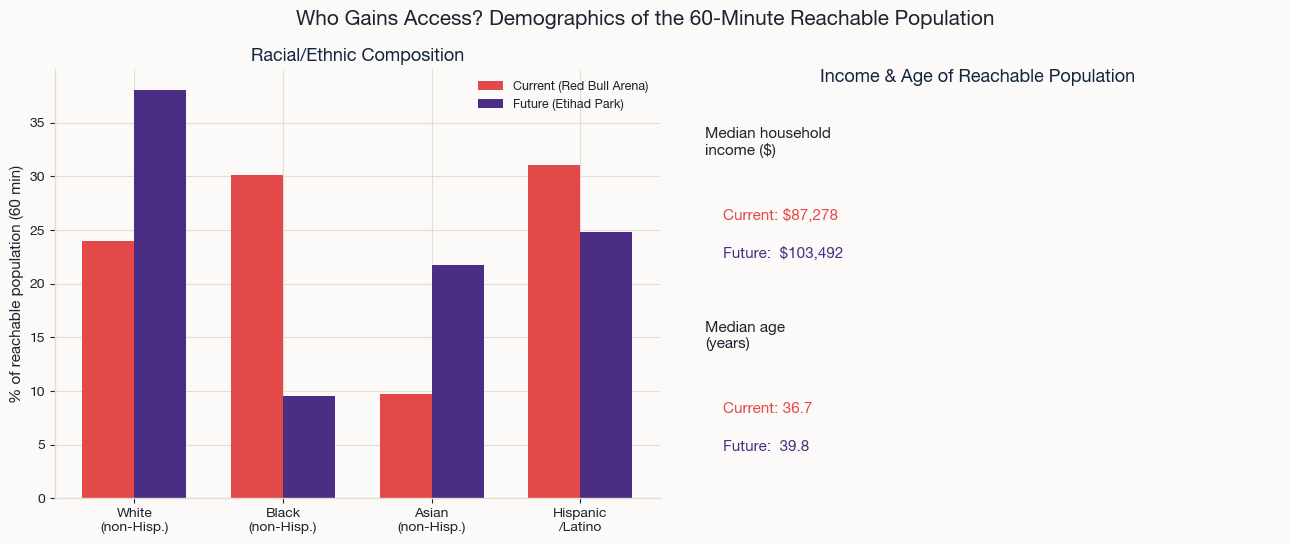

In [6]:
race_labels = {"pct_white_nh": "White\n(non-Hisp.)", "pct_black_nh": "Black\n(non-Hisp.)",
               "pct_asian_nh": "Asian\n(non-Hisp.)", "pct_hispanic_latino": "Hispanic\n/Latino"}
race_cols = list(race_labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

x = np.arange(len(race_cols))
bar_width = 0.35
cur_row = demo_df[demo_df.site_label == "current"].iloc[0]
fut_row = demo_df[demo_df.site_label == "future"].iloc[0]
ax1.bar(x - bar_width / 2, [cur_row[c] for c in race_cols], bar_width, color="#E34948", label="Current (Red Bull Arena)")
ax1.bar(x + bar_width / 2, [fut_row[c] for c in race_cols], bar_width, color="#4B2E83", label="Future (Etihad Park)")
ax1.set_xticks(x)
ax1.set_xticklabels([race_labels[c] for c in race_cols], fontsize=10)
ax1.set_ylabel("% of reachable population (60 min)")
ax1.set_title("Racial/Ethnic Composition", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)

stats = ["weighted_median_household_income", "weighted_median_age"]
stat_labels = ["Median household\nincome ($)", "Median age\n(years)"]
x2 = np.arange(len(stats))
cur_vals2 = [cur_row[s] for s in stats]
fut_vals2 = [fut_row[s] for s in stats]
# Normalize income/age to comparable bar heights isn't meaningful across units -- use two
# side-by-side single-stat mini-panels instead via twin bars with labeled values.
bars1 = ax2.bar(x2 - bar_width / 2, [1, 1], bar_width, alpha=0)  # invisible, just for spacing
ax2.axis("off")
ax2.set_title("Income & Age of Reachable Population", fontsize=13, fontweight="bold", y=0.95)
for i, (stat, label) in enumerate(zip(stats, stat_labels)):
    yb = 0.65 - i * 0.45
    ax2.text(0.05, yb + 0.15, label, fontsize=11, fontweight="bold", transform=ax2.transAxes)
    cur_v, fut_v = cur_row[stat], fut_row[stat]
    fmt = (lambda v: f"${v:,.0f}") if "income" in stat else (lambda v: f"{v:.1f}")
    ax2.text(0.08, yb, f"Current: {fmt(cur_v)}", fontsize=11, color="#E34948", transform=ax2.transAxes)
    ax2.text(0.08, yb - 0.09, f"Future:  {fmt(fut_v)}", fontsize=11, color="#4B2E83", transform=ax2.transAxes)

fig.suptitle("Who Gains Access? Demographics of the 60-Minute Reachable Population", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gotham_reachable_demographics.png"), dpi=160, facecolor="white")
plt.show()


### Absolute counts -- the number that actually matters

Percentage-of-reachable-population share can shrink even while absolute access grows, since the
total reachable population nearly quadruples. Checked explicitly: every group except one gains
in absolute terms. Black reachable population **declines** by ~63,000 people (-33%), the one
group where the move represents a real loss of access, not just a smaller share of a bigger pie.
This is reported plainly, without spin in either direction -- it's a real finding, not an
artifact of the percentage framing.


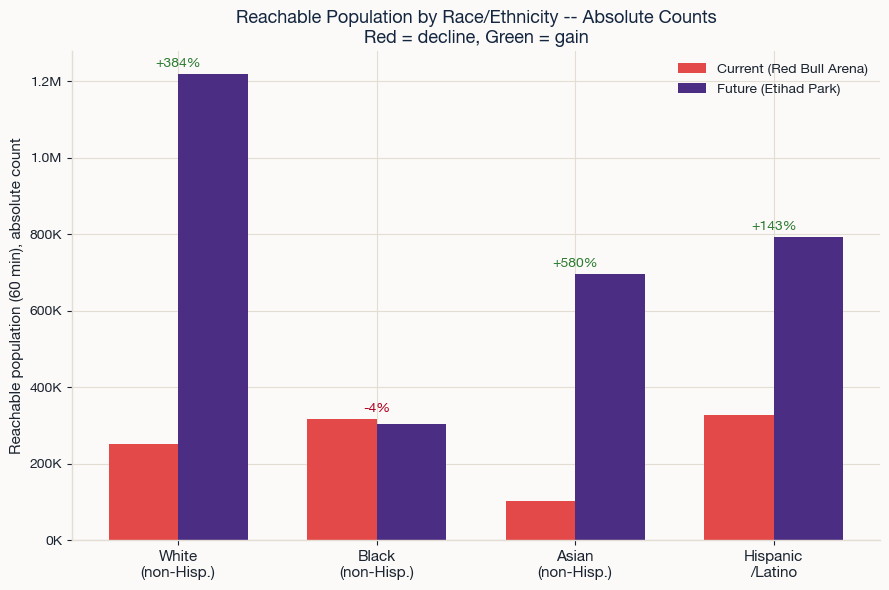

In [7]:
count_cols = {"white_nh_count": "White\n(non-Hisp.)", "black_nh_count": "Black\n(non-Hisp.)",
              "asian_nh_count": "Asian\n(non-Hisp.)", "hispanic_latino_count": "Hispanic\n/Latino"}

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(count_cols))
cur_vals = [cur_row[c] for c in count_cols]
fut_vals = [fut_row[c] for c in count_cols]
bars_cur = ax.bar(x - bar_width / 2, cur_vals, bar_width, color="#E34948", label="Current (Red Bull Arena)")
bars_fut = ax.bar(x + bar_width / 2, fut_vals, bar_width, color="#4B2E83", label="Future (Etihad Park)")

for i, (c, f) in enumerate(zip(cur_vals, fut_vals)):
    pct = (f / c - 1) * 100 if c else float("nan")
    color = "#B00020" if f < c else "#2E7D32"
    ax.annotate(f"{pct:+.0f}%", (i, max(c, f)), textcoords="offset points", xytext=(0, 5),
                ha="center", fontsize=10, fontweight="bold", color=color)

ax.set_xticks(x)
ax.set_xticklabels(list(count_cols.values()), fontsize=11)
ax.set_ylabel("Reachable population (60 min), absolute count")
ax.yaxis.set_major_formatter(lambda v, _: f"{v/1e3:.0f}K" if v < 1e6 else f"{v/1e6:.1f}M")
ax.set_title("Reachable Population by Race/Ethnicity -- Absolute Counts\nRed = decline, Green = gain", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gotham_reachable_demographics_absolute.png"), dpi=160, facecolor="white")
plt.show()


## Reconstruct filled isochrone polygons

r5py's `Isochrones` returns boundary lines (`MultiLineString`), not filled regions -- documented in `08_gtfs_isochrones.ipynb`. Reconstruct the filled polygon by wrapping the outer ring.

In [8]:
isochrones = gpd.read_file(os.path.join(DATA_PROCESSED_DIR, "nyc_isochrones_90min.geojson"))
isochrones = isochrones[isochrones["site_label"].isin(["current", "future"])]  # Red Bull Arena / Etihad Park only

def to_polygon(geom):
    lines = list(geom.geoms) if isinstance(geom, MultiLineString) else [geom]
    polys = [Polygon(l.coords) for l in lines if len(l.coords) >= 4]
    if not polys:
        return None
    polys.sort(key=lambda p: p.area, reverse=True)
    return polys[0]

isochrones["fill_geom"] = isochrones.geometry.apply(to_polygon)
isochrones_filled = isochrones.set_geometry("fill_geom", crs=isochrones.crs).drop(columns="geometry")
isochrones_filled.head()


,site_id,site_label,site_name,travel_time_minutes,fill_geom
0,NWMW84L5lz,current,Red Bull Arena,30.0,"POLYGON ((-74.1757 40.73057, -74.18007 40.7364..."
1,NWMW84L5lz,current,Red Bull Arena,45.0,"POLYGON ((-74.18395 40.77364, -74.1795 40.7756..."
2,NWMW84L5lz,current,Red Bull Arena,60.0,"POLYGON ((-74.2816 40.77007, -74.28168 40.7703..."
3,NWMW84L5lz,current,Red Bull Arena,90.0,"POLYGON ((-74.35578 40.79571, -74.35261 40.803..."
4,ETIHAD_PARK,future,Etihad Park,30.0,"POLYGON ((-73.93112 40.74206, -73.93125 40.742..."


## Tract population backdrop (NY + NJ, clipped to the metro extent)

In [9]:
tract_frames = []
for zip_name in ["tl_2023_36_tract.zip", "tl_2023_34_tract.zip"]:
    tracts = gpd.read_file(f"zip://{os.path.join(TRANSPORTATION_CENSUS, zip_name)}")
    tract_frames.append(tracts)
tracts = pd.concat(tract_frames, ignore_index=True)
tracts = gpd.GeoDataFrame(tracts, crs=tract_frames[0].crs).to_crs("EPSG:4326")
tracts["GEOID"] = tracts["GEOID"].astype(str)
tracts = tracts.merge(acs[["GEOID", "population"]], on="GEOID", how="left")

# Clip to the map extent -- both stadiums plus their 60-min isochrones, with a small buffer
MAP_BOUNDS = (-74.35, 40.60, -73.65, 40.90)  # min_lon, min_lat, max_lon, max_lat
tracts_clip = tracts.cx[MAP_BOUNDS[0]:MAP_BOUNDS[2], MAP_BOUNDS[1]:MAP_BOUNDS[3]]
print(f"{len(tracts_clip)} tracts in map extent")


2980 tracts in map extent


## Real transit lines (subway, PATH, NJ Transit rail, LIRR)

Extracted directly from the GTFS feeds in `data/raw/gtfs`
(`shapes.txt` + `trips.txt` + `routes.txt`), using each agency's own official `route_color` --
so this reads as an actual transit map, not a stylized abstraction.


In [10]:
import zipfile
import io
from shapely.geometry import LineString

TRANSPORTATION_GTFS = os.path.join("..", "data", "raw", "gtfs")

TRANSIT_FEEDS = {
    "mta_subway.zip": "Subway",
    "path.zip": "PATH",
    "njtransit_rail.zip": "NJ Transit Rail",
    "mta_lirr.zip": "LIRR",
}


def read_gtfs_csv(zf, name):
    with zf.open(name) as f:
        return pd.read_csv(io.TextIOWrapper(f, encoding="utf-8-sig"))


def extract_route_lines(zip_path, system_name):
    with zipfile.ZipFile(zip_path) as zf:
        routes = read_gtfs_csv(zf, "routes.txt")
        trips = read_gtfs_csv(zf, "trips.txt")
        shapes = read_gtfs_csv(zf, "shapes.txt")

    # One representative shape per route (the most common shape_id for that route) -- plotting
    # every branch/variant would be visual noise at this scale, one line per route is plenty to
    # read as "the subway map."
    shape_counts = trips.groupby(["route_id", "shape_id"]).size().reset_index(name="n")
    best_shape = shape_counts.sort_values("n", ascending=False).drop_duplicates("route_id")

    shapes = shapes.sort_values(["shape_id", "shape_pt_sequence"])
    lines = []
    for _, row in best_shape.iterrows():
        pts = shapes[shapes["shape_id"] == row["shape_id"]]
        if len(pts) < 2:
            continue
        route_info = routes[routes["route_id"] == row["route_id"]]
        if route_info.empty:
            continue
        color = route_info.iloc[0].get("route_color", None)
        color = f"#{color}" if isinstance(color, str) and len(color) == 6 else "#888888"
        lines.append({
            "system": system_name,
            "route_id": row["route_id"],
            "color": color,
            "geometry": LineString(zip(pts["shape_pt_lon"], pts["shape_pt_lat"])),
        })
    return lines


all_lines = []
for fname, system_name in TRANSIT_FEEDS.items():
    fpath = os.path.join(TRANSPORTATION_GTFS, fname)
    lines = extract_route_lines(fpath, system_name)
    print(f"{system_name}: {len(lines)} route lines")
    all_lines.extend(lines)

transit_lines = gpd.GeoDataFrame(all_lines, crs="EPSG:4326")
transit_lines.to_file(os.path.join(OUTPUT_DIR, "..", "data", "processed", "transit_lines.geojson"), driver="GeoJSON")
transit_lines.head()


Subway: 29 route lines
PATH: 5 route lines


NJ Transit Rail: 17 route lines
LIRR: 12 route lines


,system,route_id,color,geometry
0,Subway,L,#7C858C,"LINESTRING (-74.00258 40.73978, -73.99679 40.7..."
1,Subway,7,#9A38A1,"LINESTRING (-73.83003 40.7596, -73.83016 40.75..."
2,Subway,6,#009952,"LINESTRING (-73.82812 40.85246, -73.82915 40.8..."
3,Subway,2,#D82233,"LINESTRING (-73.94764 40.63284, -73.94841 40.6..."
4,Subway,FS,#7C858C,"LINESTRING (-73.96225 40.66161, -73.96226 40.6..."


## The map

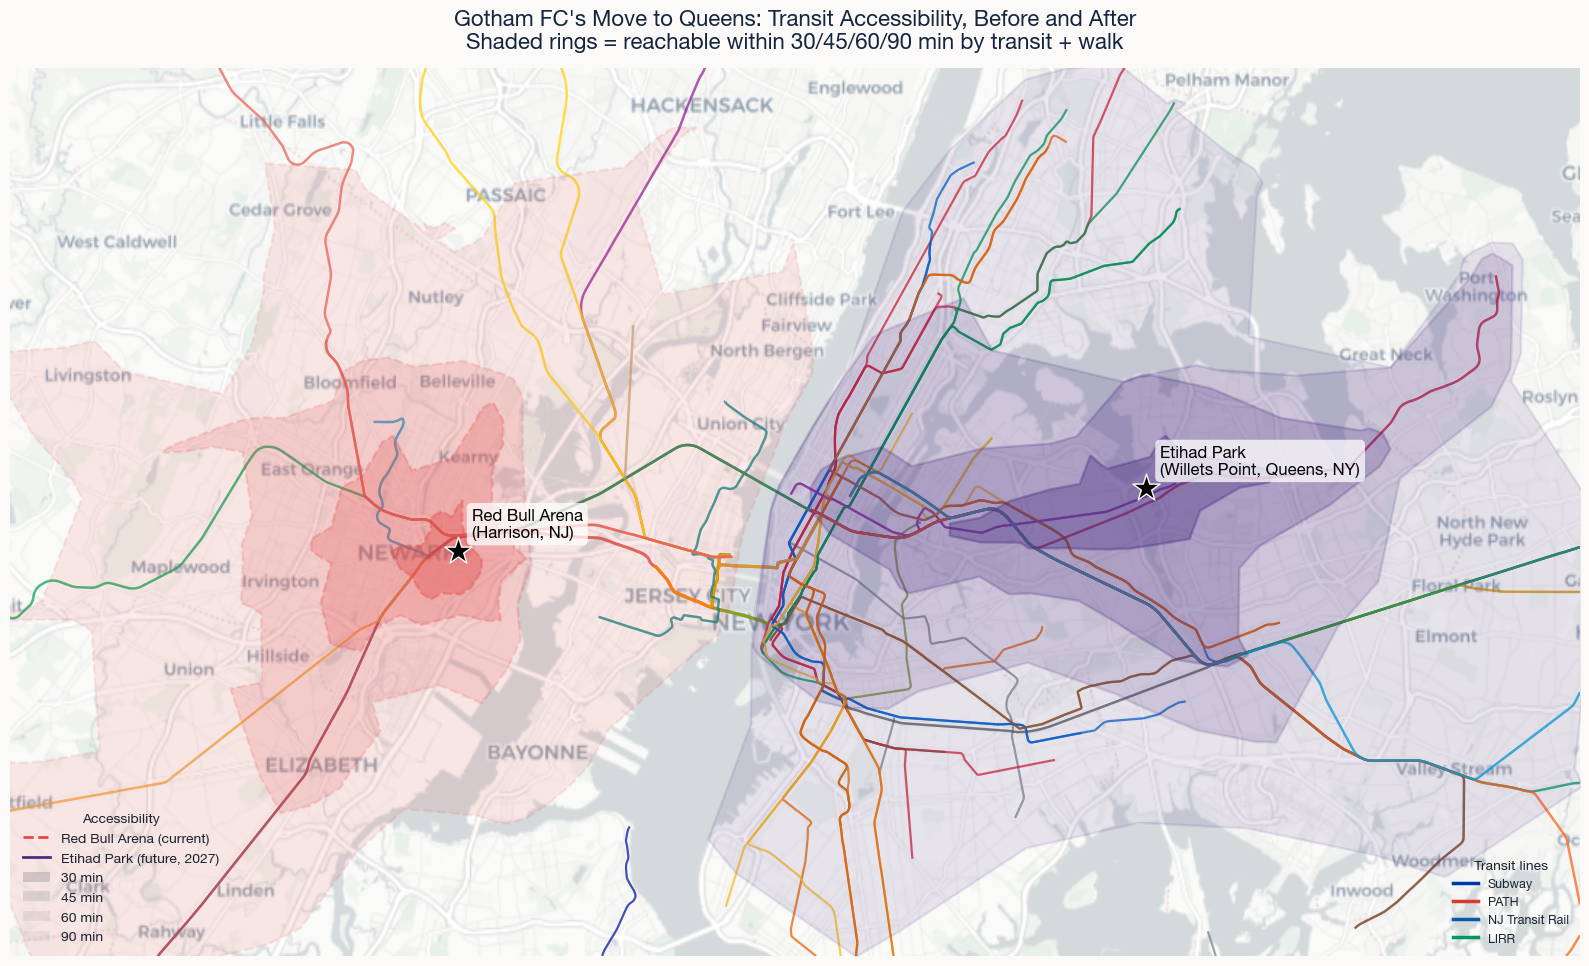

In [11]:
import contextily as cx

stadiums = pd.read_csv(os.path.join(TRANSPORTATION_PROCESSED, "relocation_stadiums.csv"))

# Map bounds are ~1.77:1 (wide) once latitude distortion is accounted for -- match figsize to
# that instead of a near-square figure, or geopandas' equal-aspect plotting letterboxes the map
# with big blank margins top/bottom.
fig, ax = plt.subplots(figsize=(16, 10.2))

ax.set_xlim(MAP_BOUNDS[0], MAP_BOUNDS[2])
ax.set_ylim(MAP_BOUNDS[1], MAP_BOUNDS[3])
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron, attribution=False)

# Real transit lines (subway/PATH/NJT rail/LIRR), official route colors, drawn under the
# isochrones so the isochrone shading still reads clearly on top.
map_box = box(*MAP_BOUNDS)
system_linewidth = {"Subway": 1.6, "PATH": 2.2, "NJ Transit Rail": 1.8, "LIRR": 1.8}
for _, row in transit_lines.iterrows():
    clipped = row.geometry.intersection(map_box)
    if clipped.is_empty:
        continue
    gpd.GeoSeries([clipped], crs=transit_lines.crs).plot(
        ax=ax, color=row["color"], linewidth=system_linewidth.get(row["system"], 1.5),
        alpha=0.75, zorder=3,
    )

# Isochrones -- current (dashed, coral) and future (solid, purple), 90/60/45/30 outer-to-inner
threshold_alpha = {90: 0.11, 60: 0.16, 45: 0.24, 30: 0.36}
site_color = {"current": "#E34948", "future": "#4B2E83"}
site_style = {"current": "--", "future": "-"}

for site_label in ["current", "future"]:
    sub = isochrones_filled[isochrones_filled["site_label"] == site_label].sort_values(
        "travel_time_minutes", ascending=False
    )
    for _, row in sub.iterrows():
        thresh = int(row["travel_time_minutes"])
        gpd.GeoSeries([row["fill_geom"]], crs=isochrones_filled.crs).plot(
            ax=ax, facecolor=site_color[site_label], edgecolor=site_color[site_label],
            alpha=threshold_alpha[thresh], linewidth=1.8, linestyle=site_style[site_label], zorder=4,
        )

# Stadium markers
for _, r in stadiums.iterrows():
    ax.scatter(r["longitude"], r["latitude"], marker="*", s=420, color="black", zorder=6,
               edgecolor="white", linewidth=1.0)
    ax.annotate(
        f"{r['name']}\n({r['city']})", (r["longitude"], r["latitude"]),
        textcoords="offset points", xytext=(10, 10), fontsize=12, fontweight="bold", zorder=6,
        color="black", bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.75, edgecolor="none"),
    )

isochrone_legend = [
    Line2D([0], [0], color="#E34948", linestyle="--", linewidth=2, label="Red Bull Arena (current)"),
    Line2D([0], [0], color="#4B2E83", linestyle="-", linewidth=2, label="Etihad Park (future, 2027)"),
    Patch(facecolor="#888888", alpha=0.36, label="30 min"),
    Patch(facecolor="#888888", alpha=0.24, label="45 min"),
    Patch(facecolor="#888888", alpha=0.16, label="60 min"),
    Patch(facecolor="#888888", alpha=0.11, label="90 min"),
]
transit_legend = [
    Line2D([0], [0], color=c, linewidth=2.5, label=s)
    for s, c in [("Subway", "#0039A6"), ("PATH", "#D93A30"), ("NJ Transit Rail", "#075AAA"), ("LIRR", "#00985F")]
]
leg1 = ax.legend(handles=isochrone_legend, loc="lower left", fontsize=10, framealpha=0.92, title="Accessibility")
ax.add_artist(leg1)
ax.legend(handles=transit_legend, loc="lower right", fontsize=9, framealpha=0.92, title="Transit lines")

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "Gotham FC's Move to Queens: Transit Accessibility, Before and After\n"
    "Shaded rings = reachable within 30/45/60/90 min by transit + walk",
    fontsize=16, fontweight="bold", pad=14,
)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gotham_isochrone_map.png"), dpi=180, facecolor="white")
plt.show()


## Reachable population by threshold (separate figure)

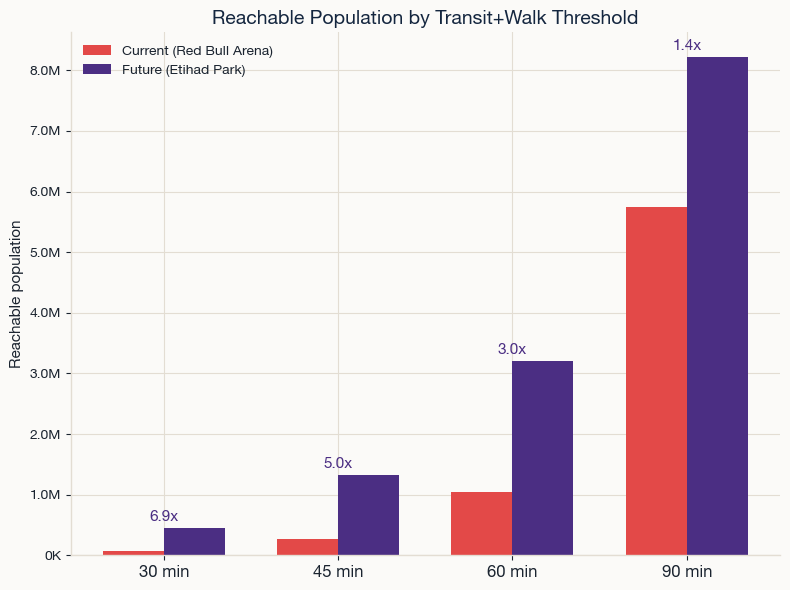

In [12]:
fig, ax_bar = plt.subplots(figsize=(8, 6))

bar_width = 0.35
x = range(len(THRESHOLDS))
cur_vals = [reach_df.query("site_label=='current' and threshold_min==@t")["reachable_population"].iloc[0] for t in THRESHOLDS]
fut_vals = [reach_df.query("site_label=='future' and threshold_min==@t")["reachable_population"].iloc[0] for t in THRESHOLDS]

ax_bar.bar([i - bar_width / 2 for i in x], cur_vals, bar_width, color="#E34948", label="Current (Red Bull Arena)")
ax_bar.bar([i + bar_width / 2 for i in x], fut_vals, bar_width, color="#4B2E83", label="Future (Etihad Park)")
ax_bar.set_xticks(list(x))
ax_bar.set_xticklabels([f"{t} min" for t in THRESHOLDS], fontsize=12)
ax_bar.set_ylabel("Reachable population", fontsize=11)
ax_bar.yaxis.set_major_formatter(lambda v, _: f"{v/1e6:.1f}M" if v >= 1e6 else f"{v/1e3:.0f}K")
ax_bar.set_title("Reachable Population by Transit+Walk Threshold", fontsize=14, fontweight="bold")
ax_bar.legend(fontsize=10, framealpha=0.9)
for spine in ["top", "right"]:
    ax_bar.spines[spine].set_visible(False)
for i, (c, f) in enumerate(zip(cur_vals, fut_vals)):
    ax_bar.annotate(f"{f/c:.1f}x", (i, max(c, f)), textcoords="offset points", xytext=(0, 5),
                     ha="center", fontsize=11, fontweight="bold", color="#4B2E83")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gotham_reachable_population_bars.png"), dpi=180, facecolor="white")
plt.show()
